In [1]:
import qutip as qt
qt.__version__

'5.0.1'

In [2]:
import scqubits
scqubits.__version__

'4.0.0'

In [1]:
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_models import *


In [2]:
# EJ = 3
# EC = EJ/4.6
# EL = EJ/21
EJ = 3
EC = EJ/4
EL = EJ/21  

qubit_level = 40


def get_shift_accurate(ele,omega_i, omega_j, omega_r):
    return abs(ele)**2 / (omega_j-omega_i-omega_r) - abs(ele)**2 / (omega_i-omega_j-omega_r)


qbt = scqubits.Fluxonium(EJ=EJ,EC=EC,EL=EL,flux=0,cutoff=110,truncated_dim=qubit_level)
evals = qbt.eigenvals(qubit_level)
elements = qbt.matrixelement_table('n_operator',evals_count = qubit_level)

def shift_diff(x):
    Er = x[0]

    shifts_from_one = [get_shift_accurate(elements[1,ql2],evals[ql2],evals[1],Er) for ql2 in range(qubit_level)] 
    shift_from_one = sum(shifts_from_one)
    shifts_from_two = [get_shift_accurate(elements[2,ql2],evals[ql2],evals[2],Er) for ql2 in range(qubit_level)] 
    shift_from_two = sum(shifts_from_two)
    return abs(shift_from_one-shift_from_two)

initial_guess = [8.65]

# Call the optimizer
result = minimize(shift_diff, initial_guess, method='Nelder-Mead')

print("Result:", result)
print("Optimal solution:", result.x)
print("Objective value:", result.fun)


Result:        message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 7.364666627721062e-07
             x: [ 8.658e+00]
           nit: 14
          nfev: 30
 final_simplex: (array([[ 8.658e+00],
                       [ 8.658e+00]]), array([ 7.365e-07,  2.114e-06]))
Optimal solution: [8.65765533]
Objective value: 7.364666627721062e-07


In [4]:


EJ = 3
EC = EJ/4
EL = EJ/21
Er = 8.32993958 #result.x[0]

g = 0.27
w_d = 8.330000924693827
amp = 0.002


max_ol = 80
max_ql = 30
g = 0.27
system = FluxoniumOscillatorSystem(
    EJ = EJ,
    EC = EC,
    EL = EL,
    Er = Er,
    g_strength = g,
    qubit_level = max_ql,
    osc_level = max_ol,
    # kappa = 0.004,
    products_to_keep=[[ql, ol] for ql in range(max_ql) for ol in range(max_ol) ],
    computaional_states = '1,2'
    )


energies=  system.hilbertspace.eigenvals(max_ql * max_ol)
def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]
def print_stats():
    print(f"\nqubit 12 transition and differential stark at different oscillator level")
    print(f"qbt freq at osc {0}:\t{(dressed_ener(2,0)-dressed_ener(1,0))}")
    ground_freq = dressed_ener(2,0)-dressed_ener(1,0)
    for i in range(1,max_ol-1):
        freq = dressed_ener(2,i)-dressed_ener(1,i)
        print(f"qbt freq at osc {i}:\t{freq:.5f}, \tdiff to at osc ground {freq - ground_freq:.5f}, {abs(freq - ground_freq)/ground_freq*100:.4f}% diff")

    print(f"\noscillator freq at qubit level:\t0 \t 1 \t 2 \t 3:")
    print(f"oscillator transition 0-1: \t{dressed_ener(0,1)-dressed_ener(0,0):.5f}\t{dressed_ener(1,1)-dressed_ener(1,0):.5f}\t{dressed_ener(2,1)-dressed_ener(2,0):.5f}\t{dressed_ener(3,1)-dressed_ener(3,0):.5f}")
    for i in range(1,max_ol-1):
        print(f"oscillator transition {i}-{i+1}: \t{dressed_ener(0,i+1)-dressed_ener(0,i):.5f}\t{dressed_ener(1,i+1)-dressed_ener(1,i):.5f}\t{dressed_ener(2,i+1)-dressed_ener(2,i):.5f}\t{dressed_ener(3,i+1)-dressed_ener(3,i):.5f}  oscillator frequency coupled to qubit 0th state compared to 00-01 (non-linearity): {(dressed_ener(0,i+1)-dressed_ener(0,i))  -(dressed_ener(0,1)-dressed_ener(0,0))}")

    print(f"")
    print(f"10-11: {(dressed_ener(1,1)-dressed_ener(1,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(1,1)-dressed_ener(1,0)))}")
    print(f"20-21: {(dressed_ener(2,1)-dressed_ener(2,0)):.4f}, diff to 00-01: {abs((dressed_ener(0,1)-dressed_ener(0,0))    -(dressed_ener(2,1)-dressed_ener(2,0)))}")
print_stats()
# plot_specturum(system.qbt, system.osc, system.hilbertspace,num_levels = 50)


qubit 12 transition and differential stark at different oscillator level
qbt freq at osc 0:	0.027129783487271908
qbt freq at osc 1:	0.02713, 	diff to at osc ground -0.00000, 0.0165% diff
qbt freq at osc 2:	0.02712, 	diff to at osc ground -0.00001, 0.0352% diff
qbt freq at osc 3:	0.02711, 	diff to at osc ground -0.00002, 0.0560% diff
qbt freq at osc 4:	0.02711, 	diff to at osc ground -0.00002, 0.0792% diff
qbt freq at osc 5:	0.02710, 	diff to at osc ground -0.00003, 0.1046% diff
qbt freq at osc 6:	0.02709, 	diff to at osc ground -0.00004, 0.1324% diff
qbt freq at osc 7:	0.02709, 	diff to at osc ground -0.00004, 0.1626% diff
qbt freq at osc 8:	0.02708, 	diff to at osc ground -0.00005, 0.1953% diff
qbt freq at osc 9:	0.02707, 	diff to at osc ground -0.00006, 0.2305% diff
qbt freq at osc 10:	0.02706, 	diff to at osc ground -0.00007, 0.2682% diff
qbt freq at osc 11:	0.02705, 	diff to at osc ground -0.00008, 0.3087% diff
qbt freq at osc 12:	0.02703, 	diff to at osc ground -0.00010, 0.3518% 

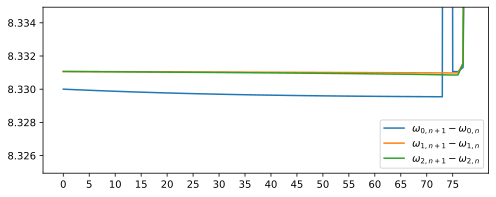

In [5]:
plt.figure(figsize = (8,3))
n_osc_lvls = max_ol-1
dressed_osc_frequencies = [[] for _ in range(3)]
for j in [0,1,2]:
    for i in range(0,max_ol-1):
        dressed_osc_frequencies[j].append(dressed_ener(j,i+1)-dressed_ener(j,i))
        
for j in [0,1,2]:
    plt.plot(list(range(max_ol-1))[:n_osc_lvls], dressed_osc_frequencies[j][:n_osc_lvls],label=rf'$\omega_{{{j},n+1}} - \omega_{{{j},n}}$')

plt.xticks(list(range(n_osc_lvls))[::5])
plt.ylim(Er-0.005, Er+0.005)
# plt.ylim(7.9,7.92)

# plt.xticklabels([str(i) for i in range(n_osc_lvls)])
plt.legend(loc='lower right')

In [6]:

evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)
def print_top_two_dressed_state(product_index):
    overlaps_with_product_state = np.abs(overlap_matrix[:, product_index])
    sorted_indices = np.argsort(overlaps_with_product_state)[::-1]
    sorted_overlaps = overlaps_with_product_state[sorted_indices]
    print(list(sorted_indices)[:2])
    print(list(sorted_overlaps)[:2])

print(f"\t\tqubit 0\t\t\tqubit 1 \t\t qubit 2")

print(f"osc lvl\t\tdressed-overlap^2\tdressed-overlap^2\tdressed-overlap^2")
for i in range(max_ol-1):
    product_index_q0 = 0 * system.osc.truncated_dim + i
    product_index_q1 = 1 * system.osc.truncated_dim + i
    product_index_q2 = 2 * system.osc.truncated_dim + i

    overlaps_with_product_state_q0 = np.abs(overlap_matrix[:, product_index_q0])
    sorted_indices_q0 = np.argsort(overlaps_with_product_state_q0)[::-1]
    sorted_overlaps_q0 = overlaps_with_product_state_q0[sorted_indices_q0]

    overlaps_with_product_state_q1 = np.abs(overlap_matrix[:, product_index_q1])
    sorted_indices_q1 = np.argsort(overlaps_with_product_state_q1)[::-1]
    sorted_overlaps_q1 = overlaps_with_product_state_q1[sorted_indices_q1]
    
    overlaps_with_product_state_q2 = np.abs(overlap_matrix[:, product_index_q2])
    sorted_indices_q2 = np.argsort(overlaps_with_product_state_q2)[::-1]
    sorted_overlaps_q2 = overlaps_with_product_state_q2[sorted_indices_q2]

    print(f"ol-{i}:\t\t{list(sorted_indices_q0)[0]}-{list(sorted_overlaps_q0)[0]**2:.3f} \t\t{list(sorted_indices_q1)[0]}-{list(sorted_overlaps_q1)[0]**2:.3f} \t\t{list(sorted_indices_q2)[0]}-{list(sorted_overlaps_q2)[0]**2:.3f}")

		qubit 0			qubit 1 		 qubit 2
osc lvl		dressed-overlap^2	dressed-overlap^2	dressed-overlap^2
ol-0:		0-1.000 		1-1.000 		2-1.000
ol-1:		7-0.989 		12-0.999 		13-0.998
ol-2:		24-0.979 		31-0.999 		32-0.997
ol-3:		50-0.968 		60-0.998 		61-0.995
ol-4:		80-0.958 		90-0.997 		91-0.994
ol-5:		110-0.947 		120-0.997 		121-0.992
ol-6:		140-0.937 		150-0.996 		151-0.990
ol-7:		170-0.926 		180-0.995 		181-0.989
ol-8:		200-0.916 		210-0.994 		211-0.987
ol-9:		230-0.905 		240-0.994 		241-0.986
ol-10:		260-0.895 		270-0.993 		271-0.984
ol-11:		290-0.885 		300-0.992 		301-0.982
ol-12:		320-0.875 		330-0.992 		331-0.981
ol-13:		350-0.865 		360-0.991 		361-0.979
ol-14:		380-0.855 		390-0.990 		391-0.977
ol-15:		410-0.845 		420-0.990 		421-0.976
ol-16:		440-0.835 		450-0.989 		451-0.974
ol-17:		470-0.825 		480-0.988 		481-0.972
ol-18:		500-0.816 		510-0.988 		511-0.970
ol-19:		530-0.806 		540-0.987 		541-0.969
ol-20:		560-0.797 		570-0.986 		571-0.967
ol-21:		590-0.787 		600-0.986 		601-0.965
ol-22:		620

In [2]:
max_ql = 20
max_ol = 40
EJ = 3
EC = EJ/4
EL = EJ/21
Er = 8.32993958

g = 0.27
w_d = 8.330000924693827
amp = 0.002


system =  FluxoniumOscillatorSystem(
                EJ = EJ,
                EC = EC,
                EL = EL,
                Er = Er,
                g_strength = g, 
                qubit_level = max_ql,
                osc_level = max_ol,
                products_to_keep=[[ql, ol] for ql in [0] for ol in range(max_ol) ],
                computaional_states = '1,2',
                )
ql = 0


kappa = 1e-3


In [3]:
tot_time =100

tlist = np.linspace(0, tot_time, tot_time)

In [4]:

result = ODEsolve_and_post_process(
    y0=system.truncate_function(qutip.basis(max_ql * max_ol, system.product_to_dressed[(ql,0)])),
    tlist = tlist,
    static_hamiltonian=system.diag_dressed_hamiltonian,
    drive_terms = [DriveTerm( 
                        driven_op= system.driven_operator,
                        pulse_shape_func=square_pulse_with_rise_fall,
                        pulse_shape_args={
                            'w_d': w_d ,
                            'amp': amp,
                            't_rise': 20,
                            't_square': tot_time
                        })],
    # c_ops = [kappa *qutip.lindblad_dissipator(system.a_trunc) ],
    c_ops = [np.sqrt(kappa) * system.a_trunc],
    e_ops = [system.a_trunc , system.a_trunc.dag()*system.a_trunc],
    method = 'qutip.mcsolve',
    file_name = 'try_mcsolve'
)

 [*         3%           ] Elapsed 192.28s / Remaining 00:01:43:36

KeyboardInterrupt: 